## Caso de Estudio

*Una institución médica desea desarrollar un sistema inteligente capaz de apoyar al especialista durante el diagnóstico de tumores mamarios.*

*El área de informática ha solicitado al equipo de Ciencia de Datos evaluar distintos algoritmos de clasificación para determinar cuál ofrece el mejor desempeño antes de integrarlo al sistema.*

In [36]:
#Carga de librerias
import warnings
import time
import pandas as pd
import matplotlib.pyplot as plt

#Librerias de ML
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
#Librerias Algoritmos
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
#Librería para evaluación
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

In [37]:
warnings.filterwarnings("ignore")

In [38]:
#Cargamos el dataset
cancer = load_breast_cancer(as_frame=True)
print(cancer.DESCR)

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

In [39]:
df = cancer.frame

In [40]:
#Exploración
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [42]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [43]:
df["target"].value_counts()

target
1    357
0    212
Name: count, dtype: int64

## Preprocesamiento 

In [44]:
#Cambiar el nombre a la variable objetivo
df.rename(
    columns={"target":"diagnostico"},
    inplace=True
)

In [45]:
df.head(1)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnostico
0,17.99,10.38,122.8,1001.0,0.1184,0.2776,0.3001,0.1471,0.2419,0.07871,...,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189,0


In [46]:
#Convertimos los valores
df["diagnostico"] = df["diagnostico"].map({
    0:"Malignant",
    1:"Benign"
})

In [47]:
#Verificamos
df.head(1)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnostico
0,17.99,10.38,122.8,1001.0,0.1184,0.2776,0.3001,0.1471,0.2419,0.07871,...,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189,Malignant


In [48]:
# Variables predictoras
X = df.drop(columns=["diagnostico"])
# Variable objetivo
y = df["diagnostico"]

In [49]:
# Separación de datos para Entrenar y Probar
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [50]:
#Escalado de los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Entrenamiento de los modelos


### Modelo 1: KNN

In [51]:
#Entrenamiento
inicio = time.time()
knn = KNeighborsClassifier(
    n_neighbors=5
)
knn.fit(
    X_train_scaled,
    y_train
)
fin = time.time()
tiempo_knn = fin-inicio

In [52]:
#Prediccion
pred_knn = knn.predict(
    X_test_scaled
)

In [53]:
#Exactitud
acc_knn = accuracy_score(
    y_test,
    pred_knn
)

print(acc_knn)

0.956140350877193


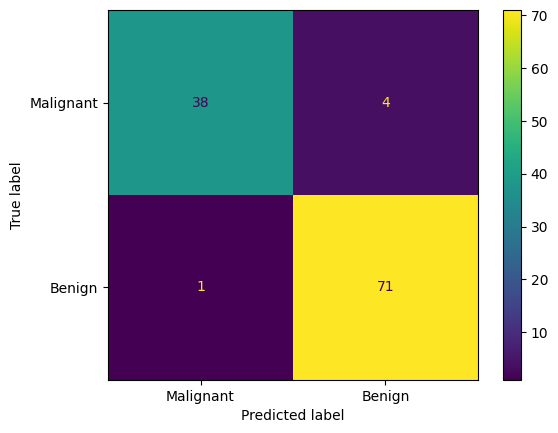

In [54]:
# Matriz de confusión
# confusion_matrix ordena las clases alfabéticamente (Benign, Malignant) si no se
# indica "labels". Hay que fijarlo para que coincida con display_labels, si no la
# gráfica sale con las etiquetas invertidas.
cm = confusion_matrix(
    y_test,
    pred_knn,
    labels=["Malignant","Benign"]
)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Malignant","Benign"]
).plot()

plt.show()

In [55]:
# Reporte de clasificación
print(classification_report(
    y_test,
    pred_knn
))

              precision    recall  f1-score   support

      Benign       0.95      0.99      0.97        72
   Malignant       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



### Modelo 2: SVM 

In [56]:
#Entrenamiento
inicio = time.time()
svm = SVC()
svm.fit(
    X_train_scaled,
    y_train
)
fin = time.time()
tiempo_svm = fin-inicio

In [57]:
#Prediccion
pred_svm = svm.predict(
    X_test_scaled
)

In [58]:
# Exactitud
acc_svm = accuracy_score(
    y_test,
    pred_svm
)

print(acc_svm)

0.9736842105263158


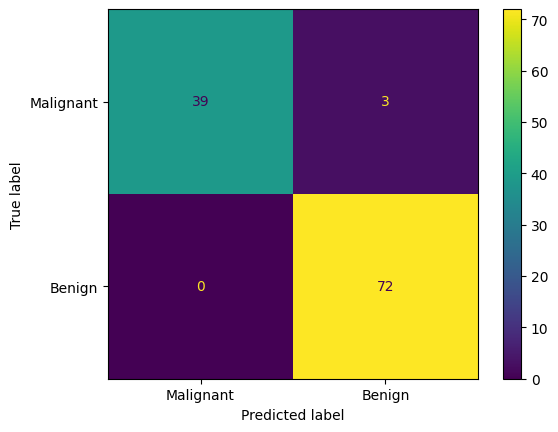

In [59]:
# Matriz de confusion
# Fijamos labels para que el orden coincida con display_labels (ver Modelo 1)
cm = confusion_matrix(
    y_test,
    pred_svm,
    labels=["Malignant","Benign"]
)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Malignant","Benign"]
).plot()

plt.show()

In [60]:
# Reporte de clasificación
print(classification_report(
    y_test,
    pred_svm
))

              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



### Modelo 3 : Random Forest

In [61]:
inicio = time.time()
rf = RandomForestClassifier(
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

fin = time.time()

tiempo_rf = fin-inicio

In [62]:
# Entrenamiento
pred_rf = rf.predict(
    X_test
)

In [63]:
# Exactitud
acc_rf = accuracy_score(
    y_test,
    pred_rf
)

print(acc_rf)

0.9736842105263158


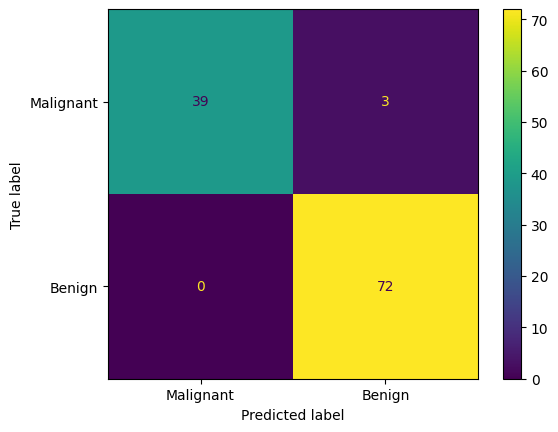

In [64]:
# Matriz de confusión
# Fijamos labels para que el orden coincida con display_labels (ver Modelo 1)
cm = confusion_matrix(
    y_test,
    pred_rf,
    labels=["Malignant","Benign"]
)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Malignant","Benign"]
).plot()

plt.show()

In [65]:
# Reporte de clasificación
print(classification_report(
    y_test,
    pred_rf
))

              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



## Comparación

In [66]:
resultados = pd.DataFrame({
    "Modelo":[
        "KNN",
        "SVM",
        "Random Forest"
    ],
    "Accuracy":[
        acc_knn,
        acc_svm,
        acc_rf
    ],
    "Tiempo Entrenamiento (s)":[
        tiempo_knn,
        tiempo_svm,
        tiempo_rf
    ]

})

In [67]:
print(resultados)

          Modelo  Accuracy  Tiempo Entrenamiento (s)
0            KNN  0.956140                  0.002514
1            SVM  0.973684                  0.005857
2  Random Forest  0.973684                  0.182884


In [68]:
#Importancia de variables
importancias = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importancias.sort_values(
    ascending=False
).head(10)

worst area              0.151412
worst concave points    0.126497
worst radius            0.093475
worst perimeter         0.083642
mean concave points     0.081082
mean perimeter          0.077126
mean radius             0.061990
mean concavity          0.050818
mean area               0.045916
worst concavity         0.030022
dtype: float64

In [70]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Todas las métricas se calculan sobre pos_label="Malignant": es la clase que
# nos interesa detectar y no es la que sklearn toma por defecto.
resultadosModelos = pd.DataFrame({
    "Modelo": ["KNN", "SVM", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, pred_knn),
        accuracy_score(y_test, pred_svm),
        accuracy_score(y_test, pred_rf)
    ],
    "Precision": [
        precision_score(y_test, pred_knn, pos_label="Malignant"),
        precision_score(y_test, pred_svm, pos_label="Malignant"),
        precision_score(y_test, pred_rf, pos_label="Malignant")
    ],
    "Recall": [
        recall_score(y_test, pred_knn, pos_label="Malignant"),
        recall_score(y_test, pred_svm, pos_label="Malignant"),
        recall_score(y_test, pred_rf, pos_label="Malignant")
    ],
    "F1 Score": [
        f1_score(y_test, pred_knn, pos_label="Malignant"),
        f1_score(y_test, pred_svm, pos_label="Malignant"),
        f1_score(y_test, pred_rf, pos_label="Malignant")
    ]
})

In [71]:
print(resultadosModelos)

          Modelo  Accuracy  Precision    Recall  F1 Score
0            KNN  0.956140   0.974359  0.904762  0.938272
1            SVM  0.973684   1.000000  0.928571  0.962963
2  Random Forest  0.973684   1.000000  0.928571  0.962963


## Conclusiones

**Resultados obtenidos:**

| Modelo | Accuracy | Precision | Recall | F1 Score | Tiempo (s) |
|---|---|---|---|---|---|
| KNN | 0.9561 | 0.9744 | 0.9048 | 0.9383 | 0.0022 |
| SVM | 0.9737 | 1.0000 | 0.9286 | 0.9630 | 0.0058 |
| Random Forest | 0.9737 | 1.0000 | 0.9286 | 0.9630 | 0.0886 |

*Precision, Recall y F1 Score calculados sobre la clase `Malignant`.*

**¿Qué métrica debemos priorizar?** No el accuracy. En un diagnóstico de tumores mamarios el error grave es el **falso negativo**: clasificar como `Benign` un tumor que en realidad es `Malignant`, porque el paciente se va sin tratamiento. Ese error lo mide el **Recall** sobre `Malignant`, y es la métrica que debe decidir el modelo. Un falso positivo, en cambio, solo deriva en estudios adicionales.

**¿Cuál fue el mejor modelo?** SVM y Random Forest empataron en las cuatro métricas: ambos obtuvieron 0.9737 de accuracy y, sobre `Malignant`, precision de 1.0000 y recall de 0.9286 (dejaron escapar 3 de los 42 tumores malignos del conjunto de prueba). El KNN quedó por debajo con recall de 0.9048 (4 falsos negativos), lo que en este contexto lo descarta pese a que su accuracy de 0.9561 parece aceptable.

**¿Cómo se rompe el empate?** Por el tiempo de entrenamiento: el SVM tardó 0.0058 s frente a 0.0886 s del Random Forest, unas 15 veces más rápido. Se recomienda el **SVM** para integrarlo al sistema.

**¿Qué variables aportan más información?** Según el `feature_importances_` del Random Forest, las cinco más relevantes fueron `worst area` (0.1514), `worst concave points` (0.1265), `worst radius` (0.0935), `worst perimeter` (0.0836) y `mean concave points` (0.0811). Las medidas "worst" (el promedio de los tres núcleos más grandes de la imagen) concentran la mayor parte de la importancia, lo que coincide con el criterio clínico de que los núcleos más irregulares y grandes son los que señalan malignidad.

**Consideraciones y limitaciones:**

- Ningún modelo alcanzó recall de 1.0000: incluso el mejor deja pasar 3 tumores malignos de 42. El sistema debe ser **apoyo al especialista, no reemplazo** del diagnóstico.
- El Random Forest se entrenó con `X_train` sin escalar, a diferencia de KNN y SVM. Esto no afecta el resultado porque los árboles son insensibles a la escala, pero rompe la simetría de la comparación.
- El conjunto de prueba es pequeño (114 registros, 42 malignos): un solo caso mal clasificado mueve el recall ~2.4 puntos, así que las diferencias entre modelos deben tomarse con cautela.
- No se ajustaron hiperparámetros (`n_neighbors=5`, `SVC()` por defecto). Una búsqueda de hiperparámetros podría mejorar el recall, que es lo que realmente interesa aquí.

---

### Correcciones aplicadas al notebook

Durante la revisión se detectaron y corrigieron tres problemas:

**1. Recall del SVM mal calculado.** En la celda de `resultadosModelos`, la fila de Recall llamaba a `precision_score` en lugar de `recall_score` para el SVM. Por eso el modelo reportaba un recall de 1.0000 (idéntico a su precision), cuando el valor real es **0.9286**. El error afectaba justo a la métrica que decide el modelo: hacía parecer que el SVM detectaba el 100% de los tumores malignos, cuando en realidad deja pasar 3 de 42. Corregido, el SVM ya no supera al Random Forest en recall — empatan, y el desempate pasa a ser el tiempo de entrenamiento.

**2. Matrices de confusión con etiquetas invertidas.** Las tres celdas de matriz de confusión pasaban `display_labels=["Malignant","Benign"]`, pero `confusion_matrix` ordena las clases alfabéticamente cuando no se le indica el parámetro `labels`, es decir `["Benign","Malignant"]`. Las gráficas mostraban los valores correctos pero con los nombres de clase al revés, por lo que los falsos negativos se leían como falsos positivos. Se agregó `labels=["Malignant","Benign"]` a las tres llamadas de `confusion_matrix` para que el orden coincida con el de `display_labels`.

**3. `classification_report` importado pero sin usar.** Estaba en la celda de importaciones desde el inicio pero nunca se llamaba. Se agregó `print(classification_report(...))` después de la matriz de confusión de cada modelo, lo que permite ver precision, recall, f1-score y support **por clase** (`Benign` y `Malignant`) y no solo el promedio global que reporta el accuracy.